In [1]:
from langchain_community.document_loaders.csv_loader import CSVLoader
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders import UnstructuredURLLoader
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter

In [2]:
loader = TextLoader("nvda1.txt")

In [3]:
loader.load()

[Document(metadata={'source': 'nvda1.txt'}, page_content="The stock of NVIDIA Corp (NASDAQNVDA) experienced a daily loss of -3.56% and a 3-month gain of 32.35%. With an Earnings Per Share (EPS) (EPS) of $1.92, the question arises is the stock significantly overvalued This article aims to provide a detailed valuation analysis of NVIDIA, offering insights into its financial strength, profitability, growth, and more. We invite you to delve into this comprehensive analysis.\n\nCompany Overview\nWarning! GuruFocus has detected 10 Warning Signs with NVDA. Click here to check it out.\n\nNVDA 30-Year Financial Data\n\nThe intrinsic value of NVDA\n\n\nNVIDIA Corp (NASDAQNVDA) is a leading designer of discrete graphics processing units that enhance the experience on computing platforms. The firm's chips are widely used in various end markets, including PC gaming and data centers. In recent years, NVIDIA has broadened its focus from traditional PC graphics applications such as gaming to more comp

In [4]:
data = loader.load()
data[0].metadata

{'source': 'nvda1.txt'}

In [5]:
loader = CSVLoader("sample_text.csv")

In [6]:
data = loader.load()

In [7]:
type(data[0])

langchain_core.documents.base.Document

In [8]:
data[0]

Document(metadata={'source': 'sample_text.csv', 'row': 0}, page_content='text: Meditation and yoga can improve mental health\ncategory: Health')

In [9]:
data[0].page_content

'text: Meditation and yoga can improve mental health\ncategory: Health'

In [10]:
data[0].metadata

{'source': 'sample_text.csv', 'row': 0}

In [11]:
loader = CSVLoader("sample_text.csv", source_column = "category")

In [12]:
loader.load()[0].metadata

{'source': 'Health', 'row': 0}

In [13]:
loader = UnstructuredURLLoader(
    urls=["https://www.moneycontrol.com/news/business/earnings/wipro-q4-results-net-profit-jumps-12-3-qoq-to-rs-3-502-crore-13890504.html"]
    
)

In [14]:
data = loader.load()

In [15]:
len(data)

1

In [16]:
data[0].metadata

{'source': 'https://www.moneycontrol.com/news/business/earnings/wipro-q4-results-net-profit-jumps-12-3-qoq-to-rs-3-502-crore-13890504.html'}

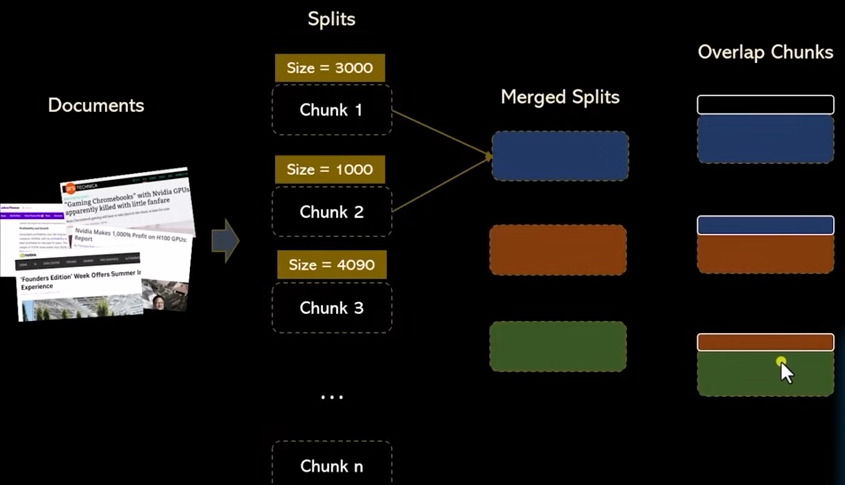

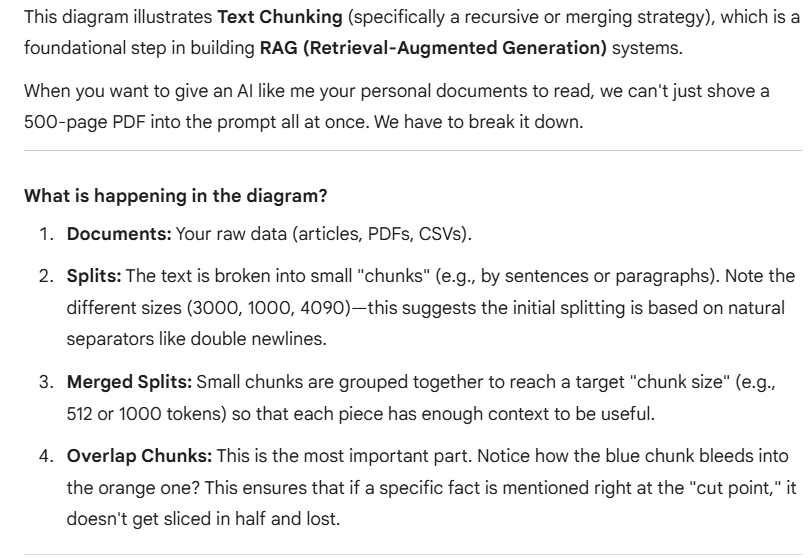

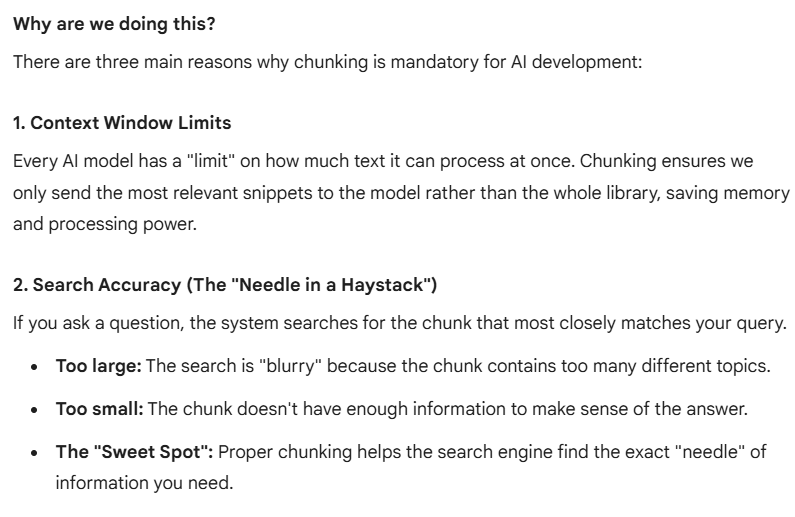

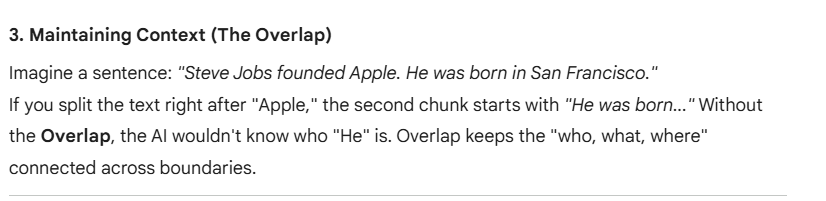

In [17]:
text = """Interstellar is a 2014 epic science fiction film co-written, directed, and produced by Christopher Nolan. 
It stars Matthew McConaughey, Anne Hathaway, Jessica Chastain, Bill Irwin, Ellen Burstyn, Matt Damon, and Michael Caine. 
Set in a dystopian future where humanity is embroiled in a catastrophic blight and famine, the film follows a group of astronauts who travel through a wormhole near Saturn in search of a new home for humankind.

Brothers Christopher and Jonathan Nolan wrote the screenplay, which had its origins in a script Jonathan developed in 2007 and was originally set to be directed by Steven Spielberg. 
Kip Thorne, a Caltech theoretical physicist and 2017 Nobel laureate in Physics,[4] was an executive producer, acted as a scientific consultant, and wrote a tie-in book, The Science of Interstellar. 
Cinematographer Hoyte van Hoytema shot it on 35 mm movie film in the Panavision anamorphic format and IMAX 70 mm. Principal photography began in late 2013 and took place in Alberta, Iceland, and Los Angeles. 
Interstellar uses extensive practical and miniature effects, and the company Double Negative created additional digital effects.

Interstellar premiered in Los Angeles on October 26, 2014. In the United States, it was first released on film stock, expanding to venues using digital projectors. The film received generally positive reviews from critics and grossed over $677 million worldwide ($715 million after subsequent re-releases), making it the tenth-highest-grossing film of 2014. 
It has been praised by astronomers for its scientific accuracy and portrayal of theoretical astrophysics.[5][6][7] Interstellar was nominated for five awards at the 87th Academy Awards, winning Best Visual Effects, and received numerous other accolades."""

### Manual approach of splitting the text into chunks

In [18]:
text[0:100]

'Interstellar is a 2014 epic science fiction film co-written, directed, and produced by Christopher N'

In [19]:
words = text.split(" ")
len(words)

264

In [20]:
chunks = []

s = ""
for word in words:
    s += word + " "
    if len(s)>200:
        chunks.append(s)
        s = ""
        
chunks.append(s)

In [21]:
len(chunks)

9

In [22]:
chunks

['Interstellar is a 2014 epic science fiction film co-written, directed, and produced by Christopher Nolan. \nIt stars Matthew McConaughey, Anne Hathaway, Jessica Chastain, Bill Irwin, Ellen Burstyn, Matt ',
 'Damon, and Michael Caine. \nSet in a dystopian future where humanity is embroiled in a catastrophic blight and famine, the film follows a group of astronauts who travel through a wormhole near Saturn in ',
 'search of a new home for humankind.\n\nBrothers Christopher and Jonathan Nolan wrote the screenplay, which had its origins in a script Jonathan developed in 2007 and was originally set to be directed by ',
 'Steven Spielberg. \nKip Thorne, a Caltech theoretical physicist and 2017 Nobel laureate in Physics,[4] was an executive producer, acted as a scientific consultant, and wrote a tie-in book, The Science of ',
 'Interstellar. \nCinematographer Hoyte van Hoytema shot it on 35 mm movie film in the Panavision anamorphic format and IMAX 70 mm. Principal photography began in late

#### To be 100% precise, it waits until it reaches at least 200 characters and then looks for the very next newline to cut; if it hits a newline earlier, it might skip it unless that newline is the best way to keep the chunk under the limit.

In [23]:
splitter = CharacterTextSplitter(
    separator = "\n",
    chunk_size = 200,
    chunk_overlap = 0
)

chunks = splitter.split_text(text)

Created a chunk of size 210, which is longer than the specified 200
Created a chunk of size 208, which is longer than the specified 200
Created a chunk of size 358, which is longer than the specified 200


In [24]:
type(chunks)

list

In [25]:
splitter = RecursiveCharacterTextSplitter(
    separators = ["\n\n", "\n", " "],
    chunk_size = 200,
    chunk_overlap = 0
)

chunks = splitter.split_text(text)

In [26]:
len(chunks)

13

In [27]:
for chunk in chunks:
    print(len(chunk))

105
120
199
10
181
197
198
8
128
191
165
198
54


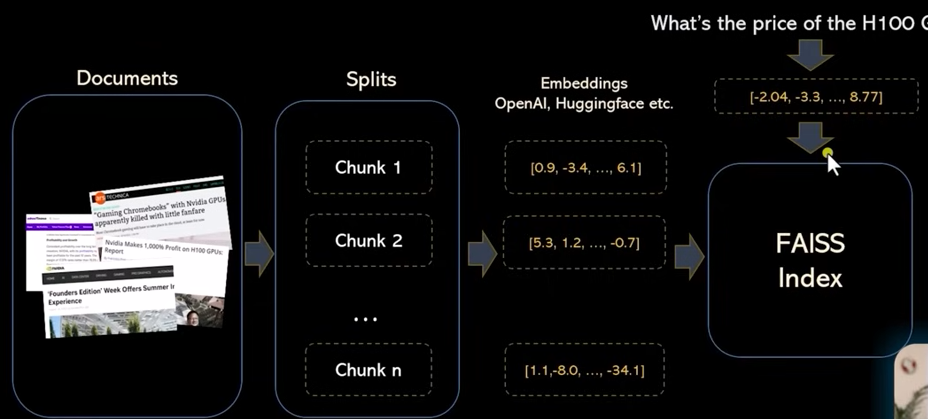

# EMBEDDINGS

In [48]:
import pandas as pd
import os
import numpy as np
from sentence_transformers import SentenceTransformer

In [49]:
pd.set_option('display.max_colwidth', 100)

In [50]:
os.listdir(".")

['.ipynb_checkpoints',
 'nvda1.txt',
 'sample_text.csv',
 'static',
 'Untitled.ipynb']

In [51]:
df = pd.read_csv('sample_text.csv')

In [52]:
df.head()

,text,category
0,Meditation and yoga can improve mental health,Health
1,"Fruits, whole grains and vegetables helps control blood pressure",Health
2,These are the latest fashion trends for this week,Fashion
3,Vibrant color jeans for male are becoming a trend,Fashion
4,The concert starts at 7 PM tonight,Event


In [53]:
encoder = SentenceTransformer('all-mpnet-base-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [54]:
vectors = encoder.encode(df['text'].tolist())

In [55]:
vectors

array([[-0.00247393,  0.03626724, -0.05290457, ..., -0.09152355,
        -0.03970002, -0.04330488],
       [-0.03357266,  0.00980519, -0.03250128, ..., -0.05165466,
         0.02245887, -0.03156182],
       [-0.01865324, -0.04051313, -0.01235388, ...,  0.00610587,
        -0.07179645,  0.02773851],
       ...,
       [-0.00066459,  0.04252128, -0.05645507, ...,  0.01315472,
        -0.03183567, -0.04357663],
       [-0.03317154,  0.03252457, -0.02484838, ...,  0.01174421,
         0.05747123,  0.00571022],
       [-0.00166393,  0.00413826, -0.04597083, ...,  0.02008526,
         0.05656242, -0.00161596]], shape=(8, 768), dtype=float32)

In [56]:
dim = vectors.shape

In [57]:
dim[1]

768

In [58]:
import faiss

In [59]:
# L2 Euclidian distance
faiss.IndexFlatL2()
index = faiss.IndexFlatL2(dim[1])
print(index)

<faiss.swigfaiss_avx2.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0x000001DECA307AB0> >


In [60]:
index.add(vectors)

In [61]:
search_query = "I want to buy a polo t-shirt"

In [62]:
query_vector = encoder.encode(search_query)

In [63]:
query_vector.shape

(768,)

In [64]:
svec = np.array(query_vector).reshape(1,-1)

In [65]:
svec.shape

(1, 768)

In [66]:
distances, I = index.search(svec, k = 2)

In [67]:
I

array([[3, 2]])

In [68]:
distances

array([[1.3844836, 1.4039094]], dtype=float32)

In [69]:
df.loc[[2,3]]

,text,category
2,These are the latest fashion trends for this week,Fashion
3,Vibrant color jeans for male are becoming a trend,Fashion


### Above you can notice that in query search it was t-shirt, but still we got that output. Because, it was semantic search and not Regular Search

 # SEARCH FUNCTION

In [75]:

def get_search(df, search_query, top_k):
    encoder = SentenceTransformer('all-mpnet-base-v2')
    query_vector = encoder.encode(search_query)
    svec = np.array(query_vector).reshape(1,-1)
    distances, I = index.search(svec, k = top_k)

    similar_indexes = []
    for i in I:
        for j in i:
            similar_indexes.append(j)
    
    return df.loc[similar_indexes]
    

In [82]:
query = "I love computer programming"
results = get_search(df, query, 2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [83]:
results

,text,category
5,Navaratri dandiya program at Expo center in Mumbai this october,Event
6,Exciting vacation destinations for your next trip,Travel


# RAG Architecture

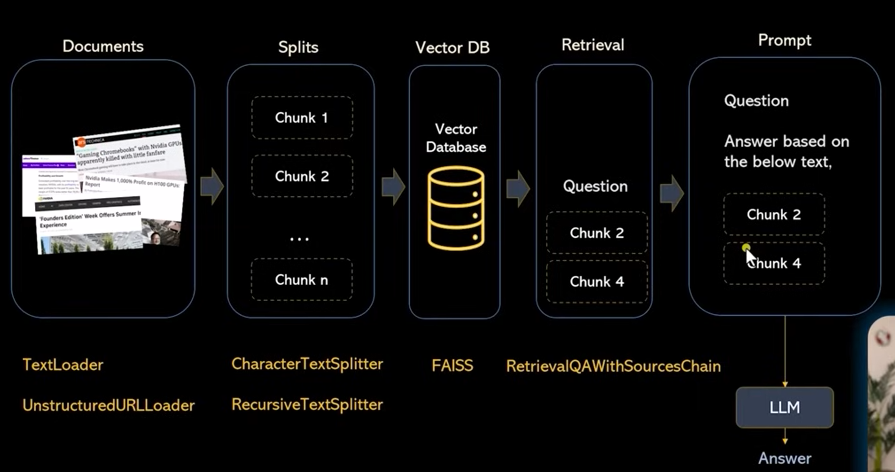

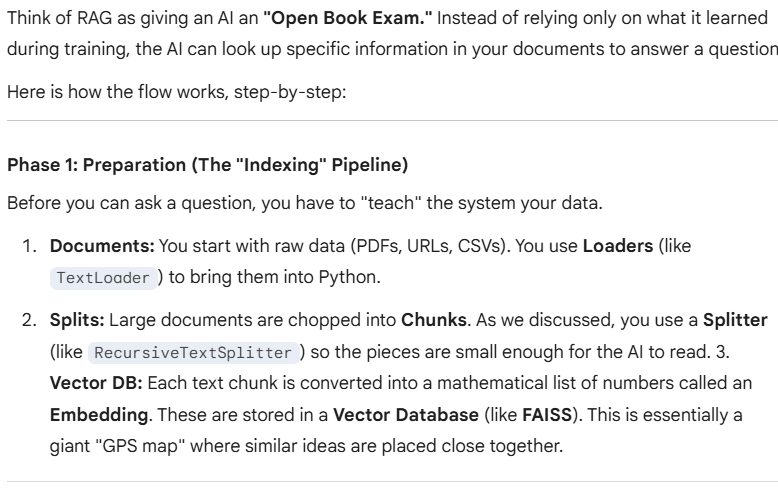

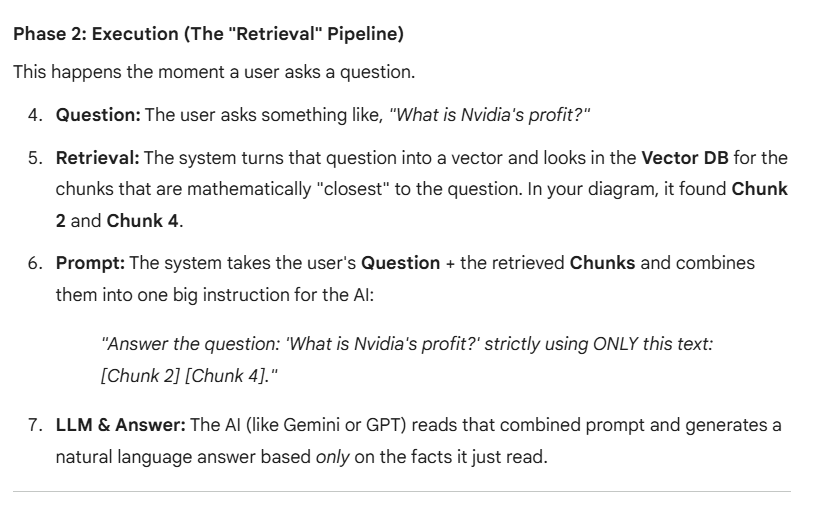

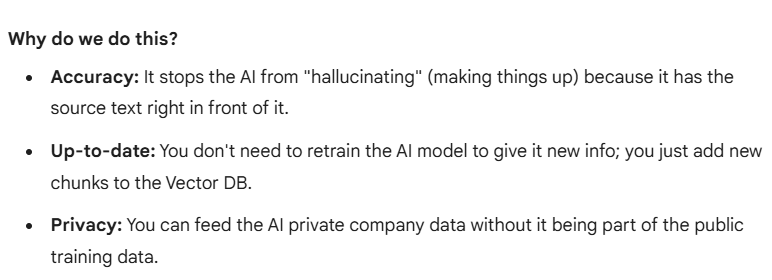

# Why we need RAGs?

### Context Limits: AI has a maximum "active memory" and cannot hold thousands of documents at once.

### Cost Efficiency: RAG only sends relevant snippets to the AI, saving you money on every question.

### Search Speed: A Vector DB acts like a high-speed index to find the exact page you need instantly.

### Better Accuracy: Providing a small "cheat sheet" prevents the AI from getting confused or making things up.

### Data Privacy: Building your own app keeps sensitive data out of public training sets.

### Source Tracking: Custom apps let you see exactly which document chunk was used for the answer.

### Easy Updates: You can add new information to your database without having to retrain the whole AI.

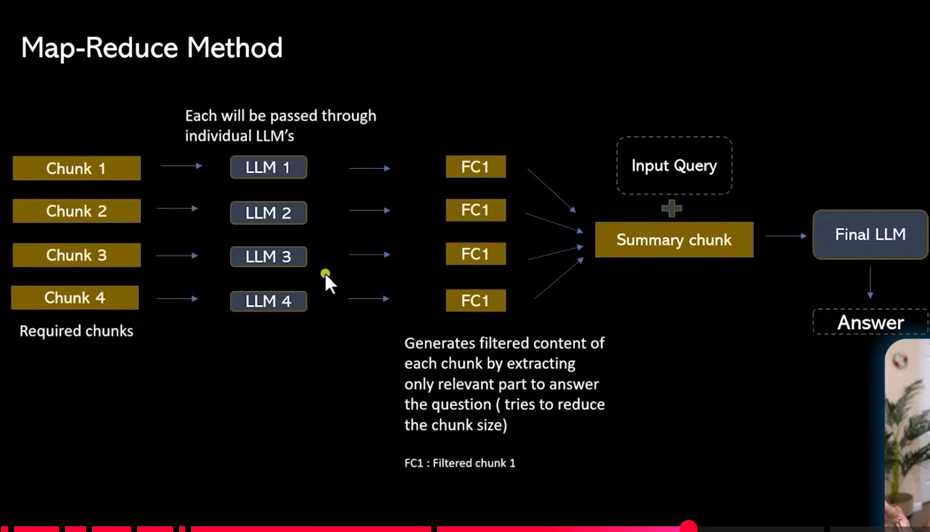

# However, what would happen if the size of the tokens from the vector DB is still very big?

## That is when we use something called Map - Reduce

## We make individual LLM Call for each chunk.

## Then we either combine the response of all these individual LLM Calls, or we feed this to AI and ask it for the best response from the previous LLM Call. this way, it works.
## Drawback: we are making too manu LLM Calls

In [90]:
import os
import streamlit as st
import pickle
import time
import langchain
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate


from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain_community.document_loaders import UnstructuredURLLoader
import faiss

In [143]:
os.environ['GEMINI_API_KEY'] = "YOUR_API_KEY"

In [92]:
llm = ChatGoogleGenerativeAI( model="gemini-3-flash-preview",temperature=0.6)

In [93]:
name = llm.invoke("I want to open a hotel for  Indian food. suggest good name")


### Load Data

In [95]:
loaders = UnstructuredURLLoader(urls=[
    "https://www.moneycontrol.com/news/business/markets/wall-street-rises-as-tesla-soars-on-ai-optimism-11351111.html",
    "https://www.moneycontrol.com/news/business/tata-motors-launches-punch-icng-price-starts-at-rs-7-1-lakh-11098751.html"
])
data = loaders.load() 
len(data)

2

In [96]:
## chunk_overlap=200 means that the last 200 characters of "Chunk 1" will be repeated at the very beginning of "Chunk 2."

In [97]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)


In [98]:
docs = text_splitter.split_documents(data)

In [99]:
len(docs)

18

In [103]:
text = docs[0].page_content.replace("\n\n", " ")

In [104]:
text

'English Hindi Gujarati Specials My Alerts Go Ad-Free Hello, Login Hello, Login Log-inor Sign-Up My Account My Profile My Portfolio My Watchlist My Alerts My Messages Price Alerts My Profile My PRO My Portfolio My Watchlist My Alerts My Messages Price Alerts Logout Loans up to ₹50 LAKHS Fixed Deposits Credit CardsLifetime Free Credit Score Loan against MFs Chat with Us Download App Follow us on: Network 18 >->MC_ENG_DESKTOP/MC_ENG_NEWS/MC_ENG_MARKETS_AS/MC_ENG_ROS_NWS_MKTS_AS_ATF_728 Moneycontrol Go PRO NowPRO Moneycontrol PRO Advertisement Remove Ad Business Markets Stocks Economy Companies Trends IPO Opinion EV Special Eco Pulse MC Learn Array\n(\n    [direction] => -1\n    [market_status] => red\n) LAMF LAMF Trending Topics Sensex Today GIFT Nifty Suraj Estate Developers Shares GHV Infra Projects Shares HDB Financial Services Shares Wall Street rises as Tesla soars on AI optimism'

In [105]:
docs[0].page_content

'English\n\nHindi\n\nGujarati\n\nSpecials\n\nMy Alerts\n\nGo Ad-Free\n\nHello, Login\n\nHello, Login\n\nLog-inor Sign-Up\n\nMy Account\n\nMy Profile\n\nMy Portfolio\n\nMy Watchlist\n\nMy Alerts\n\nMy Messages\n\nPrice Alerts\n\nMy Profile\n\nMy PRO\n\nMy Portfolio\n\nMy Watchlist\n\nMy Alerts\n\nMy Messages\n\nPrice Alerts\n\nLogout\n\nLoans up to ₹50 LAKHS\n\nFixed Deposits\n\nCredit CardsLifetime Free\n\nCredit Score\n\nLoan against MFs\n\nChat with Us\n\nDownload App\n\nFollow us on:\n\nNetwork 18\n\n>->MC_ENG_DESKTOP/MC_ENG_NEWS/MC_ENG_MARKETS_AS/MC_ENG_ROS_NWS_MKTS_AS_ATF_728\n\nMoneycontrol\n\nGo PRO NowPRO\n\nMoneycontrol PRO\n\nAdvertisement\n\nRemove Ad\n\nBusiness\n\nMarkets\n\nStocks\n\nEconomy\n\nCompanies\n\nTrends\n\nIPO\n\nOpinion\n\nEV Special\n\nEco Pulse\n\nMC Learn\n\nArray\n(\n    [direction] => -1\n    [market_status] => red\n)\n\nLAMF\n\nLAMF\n\nTrending Topics\n\nSensex Today\n\nGIFT Nifty\n\nSuraj Estate Developers Shares\n\nGHV Infra Projects Shares\n\nHDB Fina

In [106]:
# Create the text array

text_array = []
for doc in docs:
    pageContent = doc.page_content.replace("\n\n", " ")
    text_array.append(pageContent)


    


In [108]:
len(text_array)

18

In [112]:
def get_sentence_transformer(model_name):
    return SentenceTransformer(model_name)

encoder = get_sentence_transformer('all-mpnet-base-v2')
vectors = encoder.encode(text_array)
dim = vectors.shape[1]

faiss.IndexFlatL2()
index = faiss.IndexFlatL2(dim)
index.add(vectors)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [137]:
def get_search_for_query(encoder, search_query, index, top_k):
    
    query_vector = encoder.encode(search_query)
    svec = np.array(query_vector).reshape(1,-1)
    distances, I = index.search(svec, k = top_k)

    similar_indexes = []
    for i in I:
        for j in i:
            similar_indexes.append(text_array[j])
    
    return similar_indexes


def get_llm_model(model_name, temp):
    return ChatGoogleGenerativeAI(model = model_name, temperature = temp)

def generate_answer(query, retrieved_chunks, llm):
    
    context = "\n".join(retrieved_chunks)
    
    prompt = f"""
    Answer the question based only on the context below.

    Context:
    {context}

    Question:
    {query}

    Answer:
    """
    
    response = llm.invoke(prompt)
    return response

def get_final_result_from_llm(query, chunks, llm):
    
    jsonMessage = generate_answer(query, chunks, llm) 
    return jsonMessage.content[0]['text']

In [138]:
query = "I wish to invest in stock market"
received_chunks = get_search_for_query(encoder, query, index, 2)
llm = get_llm_model("gemini-3-flash-preview", 0.6)

result = get_final_result_from_llm(query, received_chunks, llm)

In [139]:
result


'Based on the context provided, you can access the following resources related to investing in the stock market:\n\n*   **Stock Markets & Stocks:** There is a section for "Stock Markets" and a directory for "Stocks" categorized from A to Z.\n*   **Investment Vehicles:** The site offers information on Mutual Funds, ETFs, and a Mutual Fund Screener.\n*   **Market Data:** You can find information on Pre-Market, Global Market, and Bonds.\n*   **Company Specific News:** The context mentions specific stock-related news such as Wipro Q4 Results, TCS, and HDB Financial Share Price.\n*   **Tools:** An EMI Calculator and Income Tax Calculator are available to assist with financial planning.'

In [140]:
text_array

['English Hindi Gujarati Specials My Alerts Go Ad-Free Hello, Login Hello, Login Log-inor Sign-Up My Account My Profile My Portfolio My Watchlist My Alerts My Messages Price Alerts My Profile My PRO My Portfolio My Watchlist My Alerts My Messages Price Alerts Logout Loans up to ₹50 LAKHS Fixed Deposits Credit CardsLifetime Free Credit Score Loan against MFs Chat with Us Download App Follow us on: Network 18 >->MC_ENG_DESKTOP/MC_ENG_NEWS/MC_ENG_MARKETS_AS/MC_ENG_ROS_NWS_MKTS_AS_ATF_728 Moneycontrol Go PRO NowPRO Moneycontrol PRO Advertisement Remove Ad Business Markets Stocks Economy Companies Trends IPO Opinion EV Special Eco Pulse MC Learn Array\n(\n    [direction] => -1\n    [market_status] => red\n) LAMF LAMF Trending Topics Sensex Today GIFT Nifty Suraj Estate Developers Shares GHV Infra Projects Shares HDB Financial Services Shares Wall Street rises as Tesla soars on AI optimism',
 'LAMF LAMF Trending Topics Sensex Today GIFT Nifty Suraj Estate Developers Shares GHV Infra Projects

In [141]:
query = "I wish to follow the latest pages/news for related to stocks/finance"
result = get_final_result_from_llm(query, get_search_for_query(encoder, query, index, 2), llm)

In [142]:
result

'Based on the context provided, you can follow the latest stocks and finance news through the following channels and sections:\n\n*   **Social Media:** Follow on Facebook, Twitter, Instagram, LinkedIn, and YouTube.\n*   **Specific News Sections:** Business, Markets, Stocks, Economy, Mutual Funds, Personal Finance, IPO News, Currencies, Commodities, Pre-Market, Global Market, and Bonds.\n*   **Trending Finance Topics:** Sensex, Wipro Q4 Results, TCS, HDB Financial Share Price, and Flipkart IPO News.\n*   **Curated Updates:** \n    *   AI News (curated every weekend).\n    *   Daily-Weekdays updates for tech trends and startup news.\n*   **Market Data:** Stocks (listed A-Z), Gold and Silver MCX Prices, and the Performance Tracker for Mutual Funds.'